# Building footprint lookup

Walks through the `Address -> Geocoding -> Overpass API -> Building polygon` steps from `scripts/get_building_footprint.py`, one stage at a time, and plots the result.

See the README for background on the Overpass API and OSMnx.

In [1]:
import os
import sys
sys.path.append("../scripts")

from get_building_footprint import (
    geocode_address,
    query_overpass_buildings,
    elements_to_polygons,
    nearest_building,
    query_overpass_roads,
    elements_to_lines,
    polygons_bounding_box,
    clip_lines_to_bbox,
)
from satellite_cache import SatelliteTileCache, GOOGLE_ATTRIBUTION

## 1. Geocode the address

In [ ]:
#address = "1600 Amphitheatre Parkway, Mountain View, CA"
address = "1095 Happy Valley Ave, SAN JOSE, CA"
radius_m = 60

lat, lon = geocode_address(address)
lat, lon

(37.3062979, -121.9913925)

## 2. Query Overpass for nearby buildings

In [3]:
elements = query_overpass_buildings(lat, lon, radius_m)
polygons = elements_to_polygons(elements)
len(polygons)

20

## 3. Pick the nearest footprint to the geocoded point

In [4]:
element, polygon = nearest_building(polygons, lat, lon)
element.get("tags", {})

{'addr:city': 'San Jose',
 'addr:housenumber': '1095',
 'addr:postcode': '95129',
 'addr:street': 'Happy Valley Avenue',
 'building': 'yes',
 'ele': '68.88',
 'height': '3.23'}

## 4. Query nearby roads

In [5]:
road_elements = query_overpass_roads(lat, lon, radius_m)
roads = elements_to_lines(road_elements)

# Overpass returns full road geometries, which run past the building bbox.
# Clip each road to the same bounding box the buildings were queried in.
bbox = polygons_bounding_box(polygons)
roads = clip_lines_to_bbox(roads, bbox)
len(roads)

5

## 5. Plot buildings and roads, with the geocoded point and the nearest footprint highlighted

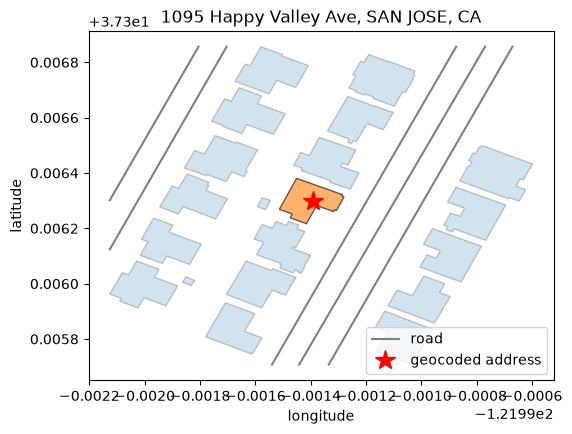

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 6))

for el, poly in polygons:
    x, y = poly.exterior.xy
    is_nearest = el is element
    ax.fill(
        x, y,
        alpha=0.6 if is_nearest else 0.2,
        edgecolor="black",
        facecolor="tab:orange" if is_nearest else "tab:blue",
    )

for i, (el, line) in enumerate(roads):
    x, y = line.xy
    ax.plot(x, y, color="gray", linewidth=1.5, label="road" if i == 0 else None)

ax.plot(lon, lat, "r*", markersize=15, label="geocoded address")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_title(address)
ax.set_aspect("equal")
ax.legend()
plt.show()

## 6. Save the nearest footprint as GeoJSON

In [7]:
import json
from get_building_footprint import to_geojson_feature

geojson = {
    "type": "FeatureCollection",
    "features": [to_geojson_feature(element, polygon)],
}

with open("../data/footprint.geojson", "w") as f:
    json.dump(geojson, f, indent=2)

## 7. Fetch satellite imagery covering the buildings

Uses the tile cache: imagery is fetched on a fixed grid at zoom 20, so only tiles not
already on disk cost an API call. The requested region is the buildings' bounding box
plus a margin, which generally spans several tiles and is stitched from them.

Requires `GOOGLE_MAPS_API_KEY` (Maps Static API enabled) to be set in the environment.

In [8]:
cache = SatelliteTileCache(cache_dir="../data/tiles")

# Pad the buildings' bbox by a small margin so roofs aren't flush against the edge.
margin_deg = 0.0003
min_lon, min_lat, max_lon, max_lat = bbox
region_bbox = (
    min_lon - margin_deg,
    min_lat - margin_deg,
    max_lon + margin_deg,
    max_lat + margin_deg,
)

i0, j0, i1, j1 = cache.tile_indices_for_bbox(region_bbox)
print(f"region spans tiles x{i0}..{i1} y{j0}..{j1} = {(i1-i0+1)*(j1-j0+1)} tiles")

image, origin = cache.get_region(region_bbox)
image.save("../data/region.png")

print(f"{image.size[0]}x{image.size[1]} px, "
      f"{cache.downloads} downloaded, {cache.hits} from cache")

region spans tiles x72089..72091 y173659..173662 = 12 tiles
1587x1640 px, 10 downloaded, 2 from cache


## 8. Display the mosaic with building outlines and roads overlaid

Outlines are projected with `region_to_pixel`. If they land on the actual roofs, the
tile grid and the `WATERMARK_PX/2` crop compensation are both correct.

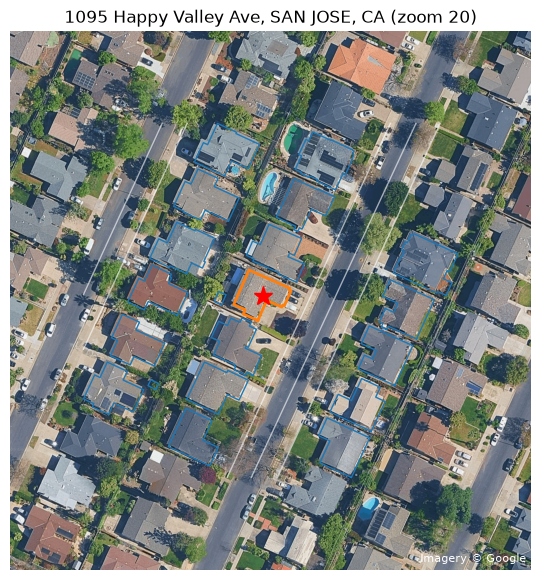

In [9]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(image)

for el, poly in polygons:
    xs, ys = poly.exterior.xy
    px, py = zip(*[cache.region_to_pixel(y, x, origin) for x, y in zip(xs, ys)])
    is_nearest = el is element
    ax.plot(
        px, py,
        color="tab:orange" if is_nearest else "tab:blue",
        linewidth=2 if is_nearest else 1,
    )

for line in (line for _, line in roads):
    px, py = zip(*[cache.region_to_pixel(y, x, origin) for x, y in zip(*line.xy)])
    ax.plot(px, py, color="white", linewidth=1, alpha=0.6)

px, py = cache.region_to_pixel(lat, lon, origin)
ax.plot(px, py, "r*", markersize=14)

ax.set_xlim(0, image.size[0])
ax.set_ylim(image.size[1], 0)
ax.axis("off")
ax.set_title(f"{address} (zoom {cache.zoom})")
ax.text(
    0.99, 0.01, GOOGLE_ATTRIBUTION,
    transform=ax.transAxes, ha="right", va="bottom",
    color="white", fontsize=8,
)
plt.show()

## 9. Display installed solar panels

Looks up every building in the region in `data/house/manifest.csv`. Addressed
buildings not already there are appended and their solar info fetched, so this
notebook and `batch_image_fetch.ipynb` write to the same table.

The step 8 overlay is redrawn with a label at each footprint's centroid: the date
Google's panel detection last captured that roof if panels were found, `NA` if they
were not. `NA` also appears, dimmed, where there is no verdict — no coverage, a
rejected match, or an unaddressed building that was never looked up. Those two cases
are drawn differently on purpose: "no panels" and "we don't know" are not the same
claim.

The label date is the *detection* capture, not the imagery under it. They are separate
Google captures and can be years apart, so a roof may be labelled from imagery newer
than the mosaic it is drawn on.

> **Why only addressed buildings get rows.** An outbuilding's centroid sits metres
> from the house it belongs to, so `findClosest` returns the *house*. Measured over
> this radius, the five unaddressed sheds matched at 8.9–14.9 m against a 1.3 m median
> for real houses — close enough to pass the 15 m guard while crediting a neighbour's
> panels to a shed. Requiring an address is the same filter `batch_image_fetch.ipynb`
> applies, and it keeps those bad labels out of the manifest. The sheds are still
> drawn, just without a verdict.

In [10]:
from pathlib import Path

from matplotlib import patheffects

from get_building_footprint import format_address, polygon_area_m2, polygon_area_sqft
from get_solar_insights import manifest_row, merge_manifest
from satellite_cache import polygon_id

FETCH_SOLAR = True  # False looks up only what is already cached, spending nothing

HOUSE_DIR = Path("../data/house")
manifest_path = HOUSE_DIR / "manifest.csv"

# Only addressed buildings become manifest rows. An outbuilding's centroid is metres
# from the house it belongs to, so findClosest returns the *house* -- measured at
# 8.9-14.9 m here against a 1.3 m median for real houses, close enough to pass the
# 15 m guard while crediting a neighbour's roof to a shed. Every building is still
# drawn below; the unaddressed ones simply have no verdict.
candidates = [
    manifest_row(
        polygon_id(poly),
        address=format_address(el.get("tags", {})),
        area_sqft=round(polygon_area_sqft(poly), 1),
        area_m2=round(polygon_area_m2(poly), 1),
        osm_type=el.get("type", "way"),
        osm_id=el.get("id", ""),
    )
    for el, poly in polygons
    if format_address(el.get("tags", {}))
]
print(f"{len(candidates)} of {len(polygons)} buildings have an address")

rows, added, filled = merge_manifest(
    manifest_path,
    candidates,
    solar_dir=HOUSE_DIR / "solar",
    api_key=os.environ.get("GOOGLE_MAPS_API_KEY"),
    image_dir=HOUSE_DIR / "images",
    fetch=FETCH_SOLAR,
    log=print,
)
solar = {r["id"]: r for r in rows}

18 of 20 buildings have an address
116 row(s) already in manifest, 18 added
18 row(s) needing solar info, 18 of them an API call
solar columns filled for 18 row(s)


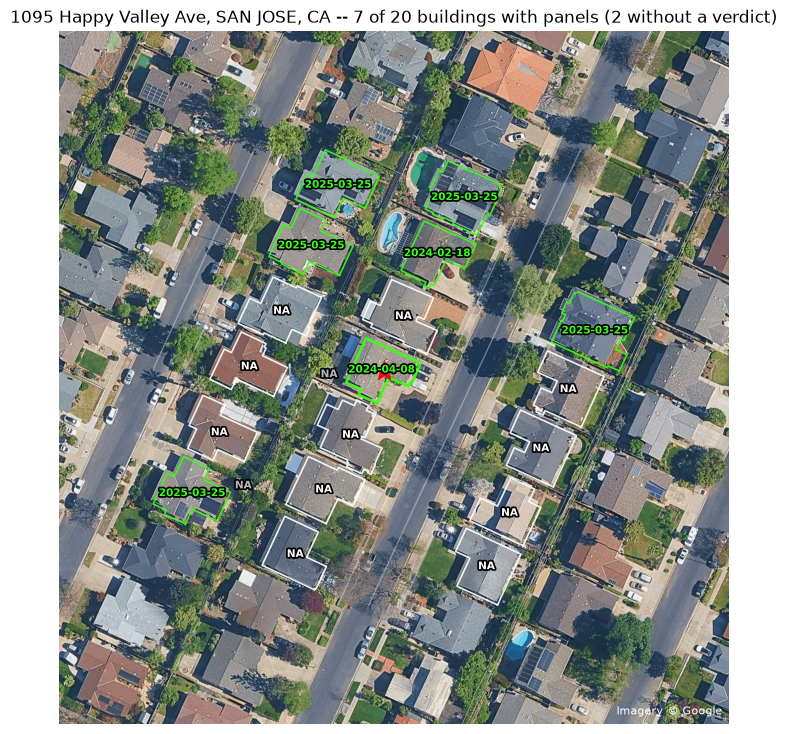

In [11]:
DETECTED = "#39ff14"  # panels found -- label is the detection capture date
NONE = "white"        # Google looked and found none
UNKNOWN = "#bbbbbb"   # no verdict: no coverage, or the match was rejected

fig, ax = plt.subplots(figsize=(9, 9))
ax.imshow(image)

counts = {DETECTED: 0, NONE: 0, UNKNOWN: 0}

for el, poly in polygons:
    xs, ys = poly.exterior.xy
    px, py = zip(*[cache.region_to_pixel(y, x, origin) for x, y in zip(xs, ys)])

    row = solar.get(polygon_id(poly), {})
    if row.get("has_panels") == "1":
        # A detected array with no capture date still counts as detected.
        label, color = row.get("panels_capture_date") or "yes", DETECTED
    elif row.get("has_panels") == "0":
        label, color = "NA", NONE
    else:
        label, color = "NA", UNKNOWN
    counts[color] += 1

    ax.plot(px, py, color=color, linewidth=2 if el is element else 1.2, alpha=0.9)

    cx, cy = cache.region_to_pixel(poly.centroid.y, poly.centroid.x, origin)
    ax.text(
        cx, cy, label,
        color=color, fontsize=7.5, fontweight="bold", ha="center", va="center",
        # the imagery underneath is arbitrary, so outline the glyphs rather than
        # trusting any single colour to stay legible over grass, roof and shadow
        path_effects=[patheffects.withStroke(linewidth=2.5, foreground="black")],
    )

for line in (line for _, line in roads):
    px, py = zip(*[cache.region_to_pixel(y, x, origin) for x, y in zip(*line.xy)])
    ax.plot(px, py, color="white", linewidth=1, alpha=0.35)

px, py = cache.region_to_pixel(lat, lon, origin)
ax.plot(px, py, "r*", markersize=14)

ax.set_xlim(0, image.size[0])
ax.set_ylim(image.size[1], 0)
ax.axis("off")
ax.set_title(
    f"{address} -- {counts[DETECTED]} of {len(polygons)} buildings with panels "
    f"({counts[UNKNOWN]} without a verdict)"
)
ax.text(
    0.99, 0.01, GOOGLE_ATTRIBUTION,
    transform=ax.transAxes, ha="right", va="bottom", color="white", fontsize=8,
)
plt.show()